In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [3]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-10'

In [4]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_haa'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$',
               'color' : color_sequence[0]}
}


selection = {
    'nocuts' : "All events"
}

process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json",
                 "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [5]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [6]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [7]:
from importlib import import_module
import sys
sys.path.insert(1, "../")

In [8]:
# ok now I want to plot b-jets and photons variables
selection = {
    "nocuts" : "All events",
    "lep_channel" : "Photon and $b$-jet sel., $\geq$ 1 lepton",
    "pT_yy_bin1" : "0$\leq p_{T}(\gamma\gamma)$< 60 GeV",
    "pT_yy_bin2" : "60$\leq p_{T}(\gamma\gamma)$< 120 GeV",
    "pT_yy_bin3" : "120$\leq p_{T}(\gamma\gamma)$< 200 GeV",
    "pT_yy_bin4" : "200$\leq p_{T}(\gamma\gamma)$< 300 GeV",
    "pT_yy_bin5" : "$p_{T}(\gamma\gamma)\geq$ 300 GeV",
}
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList
variables_list = ['E_y1', 'pT_y1', 'eta_y1', 'true_E_y1', 'true_pT_y1', 'true_eta_y1', 
                  'pT_yy', 'm_yy', 'true_pT_yy', 'true_m_yy',
                  'theta_y_y', 'cos_theta_y_y',
                  'true_theta_y_y', 'true_cos_theta_y_y',
                  'DR_y_y', 'DR_
                  'weight']
selection_string = '(higgs_decay_type==7) & (has_higgs_parent_y1==1) & (has_higgs_parent_y2==1)'

In [9]:
df = {}
sow = {}

In [10]:
for p in process.keys() :
    if p in list(df.keys()) :
        pass
    else :
        df[p] = {}
    print(p)
    for s in selection.keys() :
        if s in list(df[p].keys()) :
            pass
        else :
            print("\t\t"+s)
            df1 = []
            sow[p] = []
            for sample in process[p]['sample_list'] :
                inputfile = os.path.join(basedir, sample+"_"+s+".root")
                # get sum of weights
                #f = ROOT.TFile.Open(inputfile)
                #sow[p].append(f.Get("SumOfWeights").GetVal())
                #f.Close()
                # get sample dict
                for d in process_dicts :
                    if sample in list(d.keys()) :
                        process_dict = d.copy()
                        break
                # get sample
                with uproot.open(inputfile) as f :
                    df1.append(ak.to_dataframe(f['events'].arrays(expressions=variables_list, cut=selection_string, library='ak')))
                    df1[-1]["weight"] = df1[-1]["weight"]#/sow[p][-1]*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
            df[p][s] = pd.concat(df1, copy=True, ignore_index=True)

ttHyy
		nocuts
		lep_channel
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5


In [1]:
df1 = df['ttHyy']['nocuts'].copy()
PT_BINS = np.linspace(0, 1000., 51)
df1['pT_bin'] = np.digitize(np.abs(df1['true_pT_yy']), PT_BINS)

x = 0.5*(PT_BINS[:-1] + PT_BINS[1:])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

for ibin in range(1, len(PT_BINS)) :
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
        
    df_all = df1[df1['pT_bin']==ibin]
    observable = df_all['theta_y_y']
    mean = np.mean(observable)
    error = np.std(observable)/(len(df_all)-1)
    y[ibin-1] = mean
    yerr[ibin-1] = error
    
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], ls='none', lw=2, marker='o')
ax.hist(df1['pT_yy'], weights=df1["weight"]/df1["weight"].sum()*20,
        bins=100, range=(0,1000), histtype='stepfilled', color='grey', alpha=0.4)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T (\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\theta(\gamma\gamma)$')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
plotname = "theta_y_y_as_a_function_of_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

NameError: name 'df' is not defined

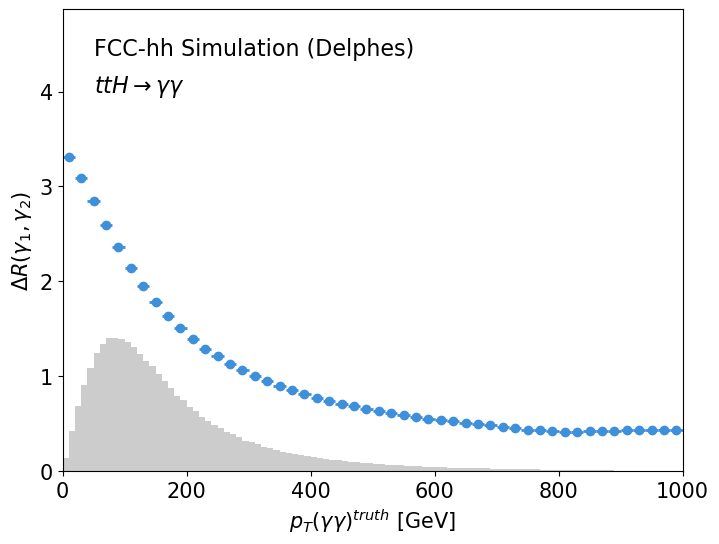

In [17]:
df1 = df['ttHyy']['nocuts'].copy()
PT_BINS = np.linspace(0, 1000., 51)
df1['pT_bin'] = np.digitize(np.abs(df1['true_pT_yy']), PT_BINS)

x = 0.5*(PT_BINS[:-1] + PT_BINS[1:])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

for ibin in range(1, len(PT_BINS)) :
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
        
    df_all = df1[df1['pT_bin']==ibin]
    observable = df_all['DR_y_y']
    mean = np.mean(observable)
    error = np.std(observable)/(len(df_all)-1)
    y[ibin-1] = mean
    yerr[ibin-1] = error
    
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], ls='none', lw=2, marker='o')
ax.hist(df1['true_pT_yy'], weights=df1["weight"]/df1["weight"].sum()*30,
        bins=100, range=(0,1000), histtype='stepfilled', color='grey', alpha=0.4)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T (\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\Delta R(\gamma_1, \gamma_2)$')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs(ymax-ymin)*0.4)
ax.set_xlim(PT_BINS[0], PT_BINS[-1])

    
plotname = "DR_y_y_as_a_function_of_true_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

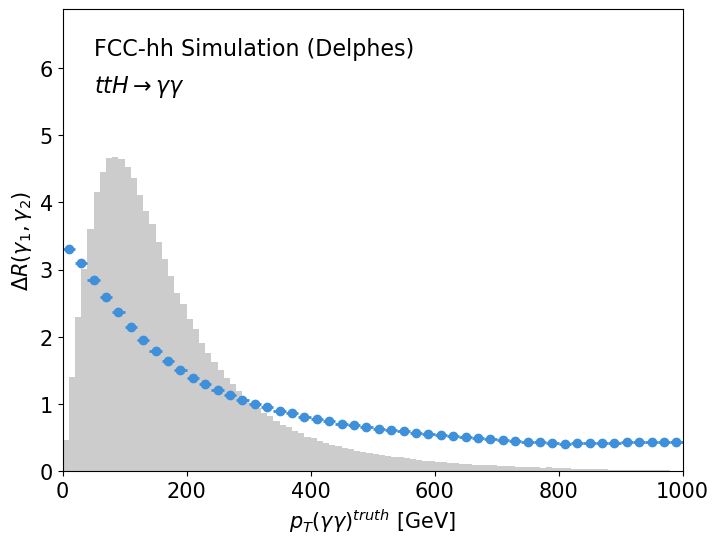

In [18]:
df1 = df['ttHyy']['nocuts'].copy()
PT_BINS = np.linspace(0, 1000., 51)
df1['pT_bin'] = np.digitize(np.abs(df1['true_pT_yy']), PT_BINS)

x = 0.5*(PT_BINS[:-1] + PT_BINS[1:])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

for ibin in range(1, len(PT_BINS)) :
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
        
    df_all = df1[df1['pT_bin']==ibin]
    observable = df_all['DR_y_y']
    mean = np.mean(observable)
    error = np.std(observable)/(len(df_all)-1)
    y[ibin-1] = mean
    yerr[ibin-1] = error
    
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], ls='none', lw=2, marker='o')
ax.hist(df1['true_pT_yy'], weights=df1["weight"]/df1["weight"].sum()*100,
        bins=100, range=(0,1000), histtype='stepfilled', color='grey', alpha=0.4)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T (\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\Delta R(\gamma_1, \gamma_2)$')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs(ymax-ymin)*0.4)
ax.set_xlim(PT_BINS[0], PT_BINS[-1])

    
plotname = "DR_y_y_as_a_function_of_true_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

In [25]:
len(df1[(df1['true_m_yy']<124.99) & (df1['true_m_yy']>125.01)])

0

In [ ]:
df1['m]

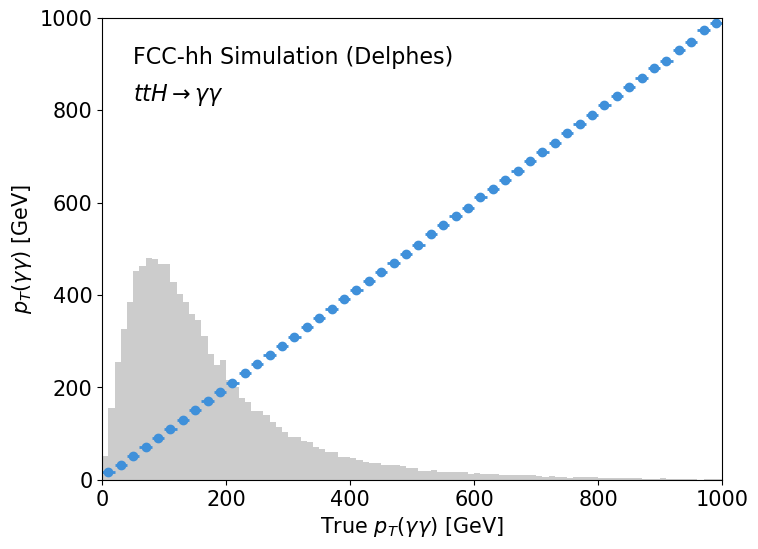

In [29]:
df1 = df['ttHyy']['nocuts'].copy()
PT_BINS = np.linspace(0, 1000., 51)
df1['pT_bin'] = np.digitize(np.abs(df1['true_pT_yy']), PT_BINS)

x = 0.5*(PT_BINS[:-1] + PT_BINS[1:])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

for ibin in range(1, len(PT_BINS)) :
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
        
    df_all = df1[df1['pT_bin']==ibin]
    observable = df_all['pT_yy'].copy()
    mean = np.mean(observable)
    error = np.std(observable)/(len(df_all)-1)
    y[ibin-1] = mean
    yerr[ibin-1] = error
    
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], ls='none', lw=2, marker='o')
ax.hist(df1['true_pT_yy'], weights=df1["weight"]/df1["weight"].sum()*1e4,
        bins=100, range=(0,1000), histtype='stepfilled', color='grey', alpha=0.4)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "True $p_T (\gamma\gamma)$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$p_T (\gamma\gamma)$ [GeV]')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(PT_BINS[0], PT_BINS[-1])
ax.set_xlim(PT_BINS[0], PT_BINS[-1])

    
plotname = "pT_yy_as_a_function_of_true_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

In [ ]:
df1 = df['ttHyy']['nocuts'].copy()
PT_BINS = np.linspace(0, 1000., 51)
df1['pT_bin'] = np.digitize(np.abs(df1['pT_yy']), PT_BINS)

x = 0.5*(PT_BINS[:-1] + PT_BINS[1:])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

for ibin in range(1, len(PT_BINS)) :
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
        
    df_all = df1[df1['pT_bin']==ibin]
    observable = df_all['DR_y_y'].copy()
    mean = np.mean(observable)
    error = np.std(observable)/(len(df_all)-1)
    y[ibin-1] = mean
    yerr[ibin-1] = error
    
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], ls='none', lw=2, marker='o')
ax.hist(df1['pT_yy'], weights=df1["weight"]/df1["weight"].sum()*20,
        bins=100, range=(0,1000), histtype='stepfilled', color='grey', alpha=0.4)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T (\gamma\gamma)$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\cos \theta(\gamma\gamma)$')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
plotname = "DR_y_y_as_a_function_of_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

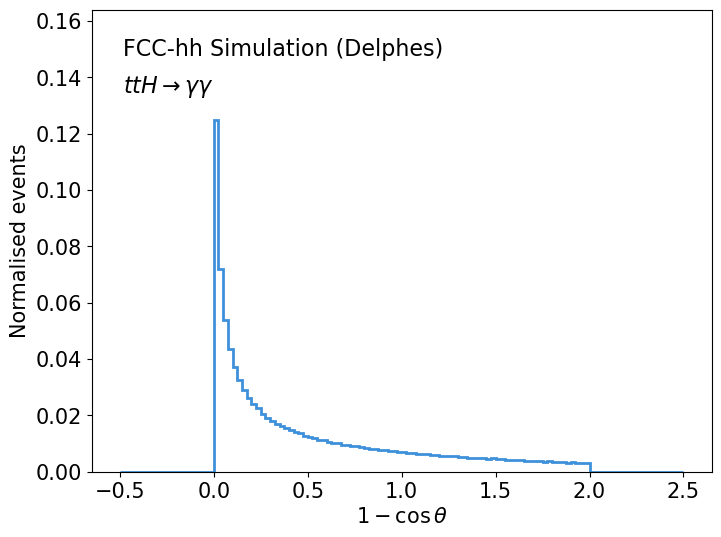

In [31]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
x = np.ones(len(df1)) - df1['cos_theta_y_y']
ax.hist(x, weights=df1["weight"]/df1["weight"].sum(),
        bins=120, range=(-0.5,2.5), histtype='step', lw=2, color=color_sequence[0], alpha=1)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = r"$1-\cos\theta$"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.25)
    
plotname = "inv_cos_theta_y_y_plot"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

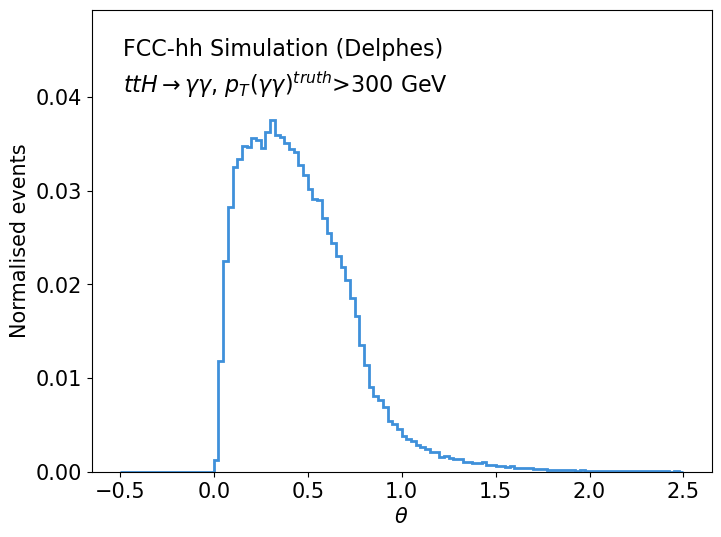

In [32]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
df2 = df1.query("true_pT_yy>300.")
ax.hist(df2["theta_y_y"], weights=df2["weight"]/df2["weight"].sum(),
        bins=120, range=(-0.5,2.5), histtype='step', lw=2, color=color_sequence[0], alpha=1)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$, $p_T(\gamma\gamma)^{truth}$>300 GeV", transform=ax.transAxes, fontsize=16)
xlabel = r"$\theta$"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.25)
    
plotname = "theta_y_y_plot_high_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

In [34]:
0.25/2./np.pi*360.

14.32394487827058

In [44]:
len(df2[df2['theta_y_y']<0.1])/len(df2)

0.06385302147126097